In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset 1

In [2]:
df_1_r = pd.read_csv("../data/dataset-1/True.csv")
df_1_f = pd.read_csv("../data/dataset-1/Fake.csv")

df_1_r.head(10)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


In [3]:
# merging real and fake news dataframes
df_1_r["target"] = 1
df_1_f["target"] = 0
df_1 = pd.concat([df_1_r, df_1_f])

df_1 = df_1.sample(frac=1).reset_index(drop=True)

In [4]:
# Drop data column
df_1.drop("date", axis=1, inplace=True)

In [10]:
df_1.describe()

,target
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [11]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   target   44898 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.4+ MB


In [14]:
df_1.isnull().sum()

title      0
text       0
subject    0
target     0
dtype: int64

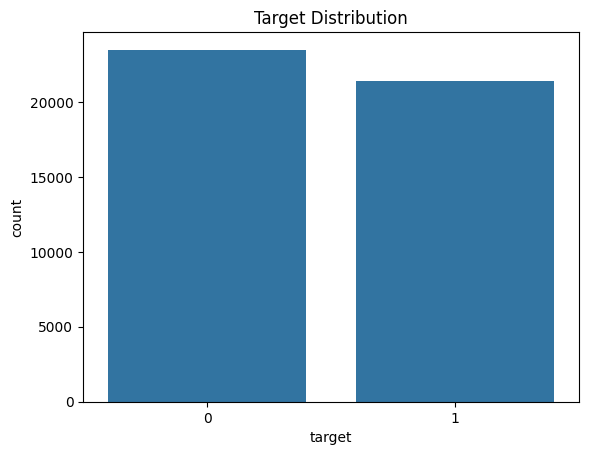

In [5]:
sns.countplot(x="target", data=df_1)
plt.title("Target Distribution")
plt.show()

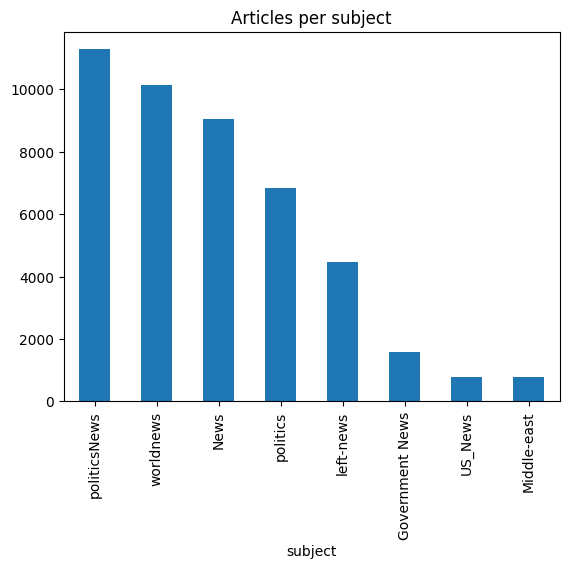

In [6]:
df_1["subject"].value_counts().plot(kind="bar")
plt.title("Articles per subject")
plt.show()

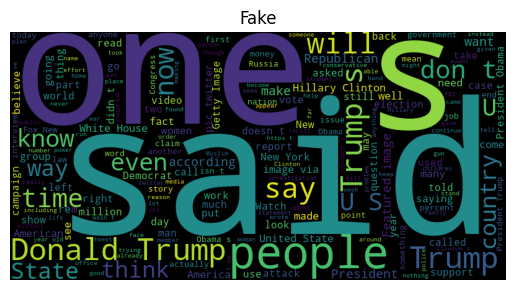

In [17]:
from wordcloud import WordCloud

text_fake = " ".join(df_1[df_1["target"] == 0]["text"].dropna())

wordcloud = WordCloud(width=800, height=400).generate(text_fake)

plt.imshow(wordcloud)
plt.title("Fake")
plt.axis("off")
plt.show()

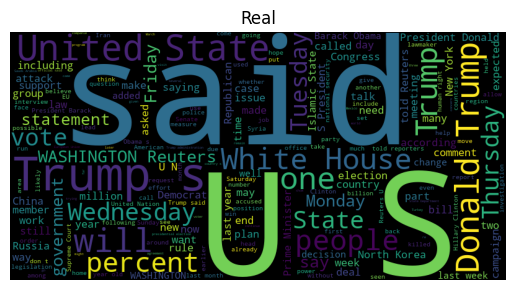

In [18]:
text_real = " ".join(df_1[df_1["target"] == 1]["text"].dropna())

wordcloud = WordCloud(width=800, height=400).generate(text_real)

plt.imshow(wordcloud)
plt.title("Real")
plt.axis("off")
plt.show()

In [21]:
df_1.to_csv("../data/cleaned/news_1.csv", index=False)